## BGL Window-Level Classification

The 4 statistical method we chose

1. **Logistic Regression**
2. **Support Vector Classification**
3. **Random Forest**
4. **Gaussian Naive Bayes**

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [ ]:
# reading data from saved feature extraction output
features_df = pd.read_csv('../artifacts/bgl_log_feature_extraction/bgl_window_features_5min.csv', parse_dates=['window_start', 'window_end'])
text_df = pd.read_csv('../artifacts/bgl_log_feature_extraction/bgl_window_text_5min.csv', parse_dates=['window_start', 'window_end'])

window_df = features_df.merge(
    text_df[['window_start', 'window_end', 'window_text']],
    on=['window_start', 'window_end'],
    how='inner',
    validate='one_to_one',
)
window_df = window_df.sort_values('window_start').reset_index(drop=True)

# Text-derived signals for anomaly intent and rare/repeating patterns.
window_text_clean = window_df['window_text'].fillna('').astype(str).str.lower()
window_df['ts_error_kw_count'] = window_text_clean.str.count(
    r'error|fail|fatal|exception|panic|timeout|denied|corrupt|segfault|abort'
).astype(float)

window_df['ts_warning_kw_count'] = window_text_clean.str.count(
    r'warn|warning|degrad|retry|slow|stall|overload'
).astype(float)

token_lists = window_text_clean.str.findall(r'[a-z][a-z0-9_]{2,}')
token_sets = token_lists.apply(set)
token_doc_freq = token_sets.explode().value_counts(dropna=True)
rare_df_cutoff = max(3, int(0.001 * len(window_df)))
rare_tokens = set(token_doc_freq[token_doc_freq <= rare_df_cutoff].index)

window_df['ts_rare_token_count'] = token_lists.apply(
    lambda toks: float(sum(1 for t in toks if t in rare_tokens))
)
window_df['ts_rare_token_repeat3'] = (
    window_df['ts_rare_token_count'].shift(1).rolling(3, min_periods=1).sum()
)

# Leakage-safe temporal features: use past windows (shift) and current-vs-past deltas.
temporal_source_cols = [
    'event_count',
    'anomaly_count',
    'digit_event_rate',
    'hex_event_rate',
    'cache_event_rate',
    'memory_event_rate',
    'network_event_rate',
    'dominant_level_share',
    'dominant_facility_share',
    'dominant_component_share',
    'mean_interarrival_seconds',
    'ts_error_kw_count',
    'ts_warning_kw_count',
    'ts_rare_token_count',
]

for col in temporal_source_cols:
    if col in window_df.columns:
        lag1 = window_df[col].shift(1)
        lag2 = window_df[col].shift(2)
        lag3 = window_df[col].shift(3)
        lag6 = window_df[col].shift(6)

        rollmean3 = lag1.rolling(3, min_periods=1).mean()
        rollmean6 = lag1.rolling(6, min_periods=1).mean()
        rollstd3 = lag1.rolling(3, min_periods=2).std()
        rollstd6 = lag1.rolling(6, min_periods=2).std()

        window_df[f'ts_{col}_lag1'] = lag1
        window_df[f'ts_{col}_lag2'] = lag2
        window_df[f'ts_{col}_lag3'] = lag3
        window_df[f'ts_{col}_lag6'] = lag6
        window_df[f'ts_{col}_rollmean3'] = rollmean3
        window_df[f'ts_{col}_rollmean6'] = rollmean6
        window_df[f'ts_{col}_rollstd3'] = rollstd3
        window_df[f'ts_{col}_rollstd6'] = rollstd6

        # Rising + trend + burstiness signals.
        window_df[f'ts_{col}_delta1'] = window_df[col] - lag1
        window_df[f'ts_{col}_delta2'] = window_df[col] - lag2
        window_df[f'ts_{col}_is_rising'] = (window_df[col] > lag1).astype(float)
        window_df[f'ts_{col}_trend36'] = rollmean3 - rollmean6
        window_df[f'ts_{col}_burstiness6'] = rollstd6 / (rollmean6.abs() + 1e-6)

# Short anomaly history from past windows only.
window_df['ts_is_anomaly_lag1'] = window_df['is_anomaly'].shift(1)
window_df['ts_is_anomaly_lag2'] = window_df['is_anomaly'].shift(2)
window_df['ts_is_anomaly_lag3'] = window_df['is_anomaly'].shift(3)
window_df['ts_anomaly_hist3'] = window_df['is_anomaly'].shift(1).rolling(3, min_periods=1).sum()
window_df['ts_anomaly_hist6'] = window_df['is_anomaly'].shift(1).rolling(6, min_periods=1).sum()

window_df['target_next_window_anomaly'] = window_df['is_anomaly'].shift(-1)
supervised_df = window_df.dropna(subset=['target_next_window_anomaly']).copy()
supervised_df['target_next_window_anomaly'] = supervised_df['target_next_window_anomaly'].astype(int)

temporal_cols_created = [c for c in supervised_df.columns if c.startswith('ts_')]

print('Merged window rows:', len(window_df))
print('Supervised rows after shifting target:', len(supervised_df))
print('Current-window anomaly rate:', round(float(window_df['is_anomaly'].mean()), 4))
print('Next-window anomaly rate:', round(float(supervised_df['target_next_window_anomaly'].mean()), 4))
print('Temporal feature count:', len(temporal_cols_created))
print('Rare-token DF cutoff:', rare_df_cutoff)
display(supervised_df.head())

Merged window rows: 14494
Supervised rows after shifting target: 14493
Current-window anomaly rate: 0.0727
Next-window anomaly rate: 0.0727
Temporal feature count: 191
Rare-token DF cutoff: 14


/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_94595/1588640541.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  window_df[f'ts_{col}_rollmean6'] = rollmean6
/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_94595/1588640541.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  window_df[f'ts_{col}_rollstd3'] = rollstd3
/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_94595/1588640541.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

,window_index,window_start,window_end,window_minutes,event_count,anomaly_count,is_anomaly,anomaly_rate,message_length_mean,message_length_std,message_length_min,message_length_max,message_token_count_mean,message_token_count_std,message_token_count_min,message_token_count_max,digit_event_rate,hex_event_rate,cache_event_rate,memory_event_rate,network_event_rate,unique_level_count,dominant_level_share,unique_facility_count,dominant_facility_share,unique_component_count,dominant_component_share,mean_interarrival_seconds,std_interarrival_seconds,timestamp_count,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,dominant_topic,window_text,ts_error_kw_count,ts_warning_kw_count,ts_rare_token_count,ts_rare_token_repeat3,ts_event_count_lag1,ts_event_count_lag2,ts_event_count_lag3,ts_event_count_lag6,ts_event_count_rollmean3,ts_event_count_rollmean6,...,ts_mean_interarrival_seconds_delta1,ts_mean_interarrival_seconds_delta2,ts_mean_interarrival_seconds_is_rising,ts_mean_interarrival_seconds_trend36,ts_mean_interarrival_seconds_burstiness6,ts_ts_error_kw_count_lag1,ts_ts_error_kw_count_lag2,ts_ts_error_kw_count_lag3,ts_ts_error_kw_count_lag6,ts_ts_error_kw_count_rollmean3,ts_ts_error_kw_count_rollmean6,ts_ts_error_kw_count_rollstd3,ts_ts_error_kw_count_rollstd6,ts_ts_error_kw_count_delta1,ts_ts_error_kw_count_delta2,ts_ts_error_kw_count_is_rising,ts_ts_error_kw_count_trend36,ts_ts_error_kw_count_burstiness6,ts_ts_warning_kw_count_lag1,ts_ts_warning_kw_count_lag2,ts_ts_warning_kw_count_lag3,ts_ts_warning_kw_count_lag6,ts_ts_warning_kw_count_rollmean3,ts_ts_warning_kw_count_rollmean6,ts_ts_warning_kw_count_rollstd3,ts_ts_warning_kw_count_rollstd6,ts_ts_warning_kw_count_delta1,ts_ts_warning_kw_count_delta2,ts_ts_warning_kw_count_is_rising,ts_ts_warning_kw_count_trend36,ts_ts_warning_kw_count_burstiness6,ts_ts_rare_token_count_lag1,ts_ts_rare_token_count_lag2,ts_ts_rare_token_count_lag3,ts_ts_rare_token_count_lag6,ts_ts_rare_token_count_rollmean3,ts_ts_rare_token_count_rollmean6,ts_ts_rare_token_count_rollstd3,ts_ts_rare_token_count_rollstd6,ts_ts_rare_token_count_delta1,ts_ts_rare_token_count_delta2,ts_ts_rare_token_count_is_rising,ts_ts_rare_token_count_trend36,ts_ts_rare_token_count_burstiness6,ts_is_anomaly_lag1,ts_is_anomaly_lag2,ts_is_anomaly_lag3,ts_anomaly_hist3,ts_anomaly_hist6,target_next_window_anomaly
0,0,2005-06-03 15:40:00,2005-06-03 15:45:00,5,645,0,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.0,1,1.0,1,1.000000,0.201211,0.337466,645,0.000019,0.000019,0.000019,0.000019,0.999864,0.000019,0.000019,0.000019,4,instruction cache parity error corrected instr...,645.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,2005-06-03 15:45:00,2005-06-03 15:50:00,5,1582,0,0,0.0,40.020228,0.804284,40,72,5.001896,0.075402,5,8,0.000632,0.000000,0.999368,0.999368,0.0,1,1.0,1,1.0,2,0.999368,0.189632,0.060522,1582,0.000008,0.000008,0.000008,0.000008,0.999945,0.000008,0.000008,0.000008,4,instruction cache parity error corrected instr...,1581.0,0.0,0.0,0.0,645.0,NaN,NaN,NaN,645.000000,645.000000,...,-0.011578,NaN,0.0,0.000000,NaN,645.0,NaN,NaN,NaN,645.000000,645.000000,NaN,NaN,936.0,NaN,1.0,0.000000,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,0
2,2,2005-06-03 15:50:00,2005-06-03 15:55:00,5,1290,0,0,0.0,39.763566,2.499440,18,72,4.965116,0.342619,2,8,0.013178,0.000000,0.986822,0.986822,0.0,1,1.0,1,1.0,2,0.999225,0.232490,0.130888,1290,0.000010,0.003795,0.000010,0.000010,0.996147,0.000010,0.000010,0.000010,4,instruction cache parity error corrected instr...,1273.0,0.0,0.0,0.0,1582.0,645.0,NaN,NaN,1113.500000,1113.500000,...,0.042857,0.031279,1.0,0.000000,0.041894,1581.0,645.0,NaN,NaN,1

## Experimental Setup

Our experiment uses **non-binary t+1 prediction** only.


Each sample is the current 5-minute window, and the target is the next-window severity class:
- `0`: no anomaly in next window
- `1`: exactly one anomaly in next window
- `2`: burst anomalies in next window (`2+`)

Features combine manual/temporal window signals with TF-IDF text embeddings reduced by SVD.


Models compared (same feature matrix for fairness): Logistic Regression, Linear SVC, Random Forest, and Gaussian Naive Bayes.


Primary selection metric is **macro-F1** to avoid majority-class bias, yet we still report weighted-F1 and accuracy as secondary metrics.

In [11]:
base_numeric_feature_cols = [
    'event_count',
    'message_length_mean',
    'message_length_std',
    'message_length_min',
    'message_length_max',
    'message_token_count_mean',
    'message_token_count_std',
    'message_token_count_min',
    'message_token_count_max',
    'digit_event_rate',
    'hex_event_rate',
    'cache_event_rate',
    'memory_event_rate',
    'network_event_rate',
    'unique_level_count',
    'dominant_level_share',
    'unique_facility_count',
    'dominant_facility_share',
    'unique_component_count',
    'dominant_component_share',
    'mean_interarrival_seconds',
    'std_interarrival_seconds',
    'lda_topic_0',
    'lda_topic_1',
    'lda_topic_2',
    'lda_topic_3',
    'lda_topic_4',
    'lda_topic_5',
    'lda_topic_6',
    'lda_topic_7',
]

temporal_feature_cols = sorted([c for c in supervised_df.columns if c.startswith('ts_')])
numeric_feature_cols = base_numeric_feature_cols + temporal_feature_cols

missing_cols = [col for col in numeric_feature_cols if col not in supervised_df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns: {missing_cols}')

# Non-binary target: next-window anomaly severity (0, 1, 2+).
severity_target = (
    window_df['anomaly_count']
    .shift(-1)
    .dropna()
    .astype(int)
    .clip(upper=2)
    .reset_index(drop=True)
)

supervised_df = supervised_df.reset_index(drop=True).copy()
supervised_df['target_next_window_severity'] = severity_target.iloc[:len(supervised_df)].to_numpy()

y_all = supervised_df['target_next_window_severity'].astype(int).copy()

candidate_fracs = np.linspace(0.65, 0.9, 11)
split_idx = None
for frac in candidate_fracs:
    candidate_idx = int(len(supervised_df) * frac)
    candidate_idx = min(max(candidate_idx, 1), len(supervised_df) - 1)
    y_train_candidate = y_all.iloc[:candidate_idx]
    y_test_candidate = y_all.iloc[candidate_idx:]
    if y_train_candidate.nunique() > 1 and y_test_candidate.nunique() > 1:
        split_idx = candidate_idx
        break

if split_idx is None:
    split_idx = int(len(supervised_df) * 0.8)
    split_idx = min(max(split_idx, 1), len(supervised_df) - 1)

train_df = supervised_df.iloc[:split_idx].copy()
test_df = supervised_df.iloc[split_idx:].copy()
y_train_mc = train_df['target_next_window_severity'].astype(int).copy()
y_test_mc = test_df['target_next_window_severity'].astype(int).copy()

print('Train windows:', len(train_df))
print('Test windows:', len(test_df))
print('Train class distribution:')
print(y_train_mc.value_counts(normalize=True).sort_index().rename('ratio').round(4))
print('Test class distribution:')
print(y_test_mc.value_counts(normalize=True).sort_index().rename('ratio').round(4))
print('Base numeric features:', len(base_numeric_feature_cols))
print('Temporal features:', len(temporal_feature_cols))
print('Total numeric features:', len(numeric_feature_cols))

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    ngram_range=(1, 2),
    stop_words='english',
)
train_tfidf = tfidf_vectorizer.fit_transform(train_df['window_text'].fillna(''))
test_tfidf = tfidf_vectorizer.transform(test_df['window_text'].fillna(''))

if train_tfidf.shape[1] < 3:
    raise ValueError('TF-IDF vocabulary is too small for SVD features.')

svd_components = min(25, train_tfidf.shape[1] - 1)
svd_components = max(2, svd_components)
tfidf_svd = TruncatedSVD(n_components=svd_components, random_state=42)
train_text_features = tfidf_svd.fit_transform(train_tfidf)
test_text_features = tfidf_svd.transform(test_tfidf)

X_train_base = train_df[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
X_test_base = test_df[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
X_train = np.hstack([X_train_base, train_text_features])
X_test = np.hstack([X_test_base, test_text_features])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature matrix shape:', X_train_scaled.shape, X_test_scaled.shape)

Train windows: 9420
Test windows: 5073
Train class distribution:
target_next_window_severity
0    0.9167
1    0.0206
2    0.0627
Name: ratio, dtype: float64
Test class distribution:
target_next_window_severity
0    0.9470
1    0.0101
2    0.0430
Name: ratio, dtype: float64
Base numeric features: 30
Temporal features: 191
Total numeric features: 221
Feature matrix shape: (9420, 246) (5073, 246)


In [19]:
models = {
    'Logistic Regression': {
        'option': '(a)',
        'model': LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42,
        ),
    },
    'Linear SVC': {
        'option': '(b)',
        'model': LinearSVC(class_weight='balanced', random_state=42),
    },
    'Random Forest': {
        'option': '(c)',
        'model': RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42,
        ),
    },
    'Gaussian Naive Bayes': {
        'option': '(d)',
        'model': GaussianNB(),
    },
}

# chronological validation split for optional decision-policy tuning.
val_size = max(200, int(len(X_train_scaled) * 0.2))
val_size = min(val_size, max(1, len(X_train_scaled) - 1))
inner_split_idx = len(X_train_scaled) - val_size

X_fit = X_train_scaled[:inner_split_idx]
y_fit = y_train_mc.iloc[:inner_split_idx]
X_val = X_train_scaled[inner_split_idx:]
y_val = y_train_mc.iloc[inner_split_idx:]

use_val_split = y_fit.nunique() > 1 and y_val.nunique() > 1

results = []
predictions = {}
svc_relaxed_policy = None

for model_name, info in models.items():
    model = info['model']

    if model_name == 'Linear SVC' and use_val_split:
        # tune additive class biases on validation to relax anomaly prediction.
        model.fit(X_fit, y_fit)
        val_scores = model.decision_function(X_val)
        class_labels = model.classes_.astype(int)
        class_to_idx = {c: i for i, c in enumerate(class_labels)}

        # wider search to allow a more relaxed anomaly decision boundary.
        bias_grid_c1 = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
        bias_grid_c2 = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]

        # prefer macro-F1 while nudging toward stronger minority recall.
        best_bias = {'c1': 0.0, 'c2': 0.0, 'score': -1.0, 'macro': 0.0, 'rec1': 0.0, 'rec2': 0.0}

        for b1 in bias_grid_c1:
            for b2 in bias_grid_c2:
                adjusted = np.array(val_scores, copy=True)
                if 1 in class_to_idx:
                    adjusted[:, class_to_idx[1]] += b1
                if 2 in class_to_idx:
                    adjusted[:, class_to_idx[2]] += b2

                pred_val = class_labels[np.argmax(adjusted, axis=1)]
                macro = f1_score(y_val, pred_val, average='macro', zero_division=0)
                rec1 = recall_score((y_val == 1).astype(int), (pred_val == 1).astype(int), zero_division=0)
                rec2 = recall_score((y_val == 2).astype(int), (pred_val == 2).astype(int), zero_division=0)

                # Recall-aware objective (still macro-F1 dominant).
                objective = macro + 0.10 * rec2 + 0.05 * rec1
                candidate = (objective, macro, rec2, rec1)
                current = (best_bias['score'], best_bias['macro'], best_bias['rec2'], best_bias['rec1'])
                if candidate > current:
                    best_bias = {
                        'c1': float(b1),
                        'c2': float(b2),
                        'score': float(objective),
                        'macro': float(macro),
                        'rec1': float(rec1),
                        'rec2': float(rec2),
                    }

        svc_relaxed_policy = best_bias

        # refit on full training and apply tuned biases on test scores
        model.fit(X_train_scaled, y_train_mc)
        test_scores = model.decision_function(X_test_scaled)
        adjusted_test = np.array(test_scores, copy=True)
        class_to_idx = {c: i for i, c in enumerate(class_labels)}
        if 1 in class_to_idx:
            adjusted_test[:, class_to_idx[1]] += best_bias['c1']
        if 2 in class_to_idx:
            adjusted_test[:, class_to_idx[2]] += best_bias['c2']

        y_pred = class_labels[np.argmax(adjusted_test, axis=1)]
        tuning_note = f"relaxed_bias(c1={best_bias['c1']:.2f}, c2={best_bias['c2']:.2f})"
    else:
        model.fit(X_train_scaled, y_train_mc)
        y_pred = model.predict(X_test_scaled).astype(int)
        tuning_note = 'default_decision'

    predictions[model_name] = y_pred

    class_recalls = recall_score(
        y_test_mc,
        y_pred,
        average=None,
        labels=[0, 1, 2],
        zero_division=0,
    )

    results.append({
        'method_option': info['option'],
        'model': model_name,
        'decision_policy': tuning_note,
        'macro_f1': float(f1_score(y_test_mc, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_test_mc, y_pred, average='weighted', zero_division=0)),
        'micro_f1': float(f1_score(y_test_mc, y_pred, average='micro', zero_division=0)),
        'accuracy': float(accuracy_score(y_test_mc, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_test_mc, y_pred)),
        'recall_class_0': float(class_recalls[0]),
        'recall_class_1': float(class_recalls[1]),
        'recall_class_2plus': float(class_recalls[2]),
        'prediction_rate_class_0': float(np.mean(y_pred == 0)),
        'prediction_rate_class_1': float(np.mean(y_pred == 1)),
        'prediction_rate_class_2plus': float(np.mean(y_pred == 2)),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(['macro_f1', 'weighted_f1', 'accuracy'], ascending=False)
    .reset_index(drop=True)
)

print('Non-binary t+1 model comparison (0/1/2+):')
display(results_df)
if svc_relaxed_policy is not None:
    print('Linear SVC relaxed policy (validation-selected):', svc_relaxed_policy)

best_model_name = results_df.iloc[0]['model']
best_pred = predictions[best_model_name]

print('Best model by macro-F1:', best_model_name)
print('Best macro-F1:', round(float(results_df.iloc[0]['macro_f1']), 4))
print('Best weighted-F1:', round(float(results_df.iloc[0]['weighted_f1']), 4))
print('Best accuracy:', round(float(results_df.iloc[0]['accuracy']), 4))

print(
    classification_report(
        y_test_mc,
        best_pred,
        labels=[0, 1, 2],
        target_names=['0', '1', '2+'],
        digits=4,
        zero_division=0,
    )
)

Non-binary t+1 model comparison (0/1/2+):


,method_option,model,decision_policy,macro_f1,weighted_f1,micro_f1,accuracy,balanced_accuracy,recall_class_0,recall_class_1,recall_class_2plus,prediction_rate_class_0,prediction_rate_class_1,prediction_rate_class_2plus
0,(b),Linear SVC,"relaxed_bias(c1=0.05, c2=0.20)",0.425692,0.917563,0.915238,0.915238,0.434573,0.955454,0.137255,0.211009,0.943229,0.022866,0.033905
1,(c),Random Forest,default_decision,0.341483,0.923369,0.946777,0.946777,0.342022,0.998543,0.000000,0.027523,0.997240,0.000000,0.002760
2,(a),Logistic Regression,default_decision,0.334999,0.784617,0.690321,0.690321,0.427570,0.713364,0.294118,0.275229,0.698206,0.191603,0.110191
3,(d),Gaussian Naive Bayes,default_decision,0.241728,0.553528,0.401143,0.401143,0.396929,0.410699,0.647059,0.133028,0.397201,0.553124,0.049675


Linear SVC relaxed policy (validation-selected): {'c1': 0.05, 'c2': 0.2, 'score': 0.4274406533842806, 'macro': 0.39689108441876336, 'rec1': 0.09375, 'rec2': 0.25862068965517243}
Best model by macro-F1: Linear SVC
Best macro-F1: 0.4257
Best weighted-F1: 0.9176
Best accuracy: 0.9152
              precision    recall  f1-score   support

           0     0.9592    0.9555    0.9573      4804
           1     0.0603    0.1373    0.0838        51
          2+     0.2674    0.2110    0.2359       218

    accuracy                         0.9152      5073
   macro avg     0.4290    0.4346    0.4257      5073
weighted avg     0.9205    0.9152    0.9176      5073



## Evaluation and Visualization Setup

- confusion matrix to understand how models are predicting on each category 
- time series GT vs Prediction graph for over time prediction visualization

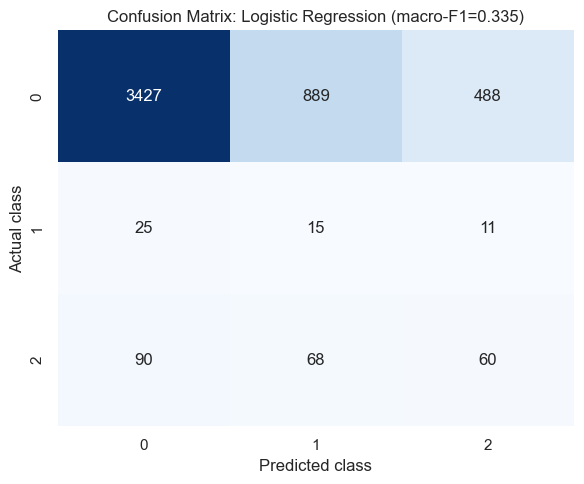

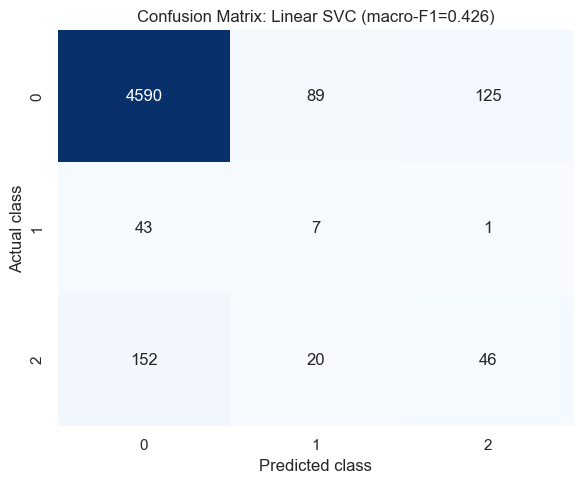

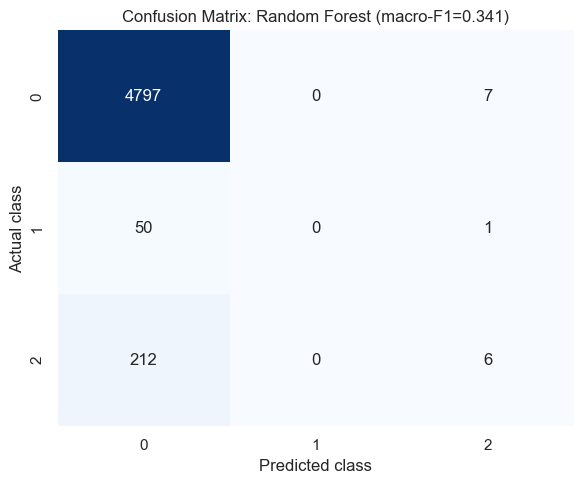

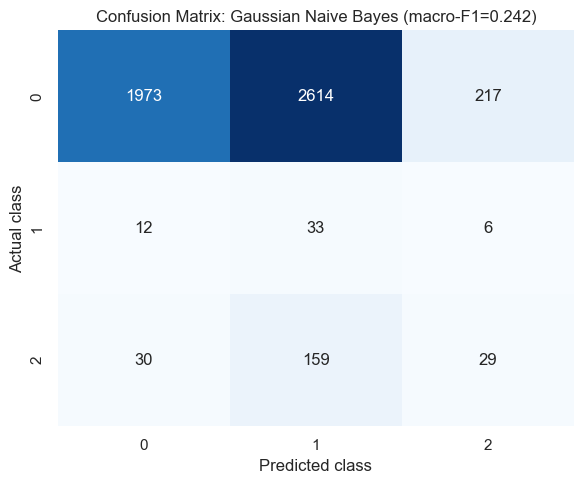

In [13]:
# confusion matrix plot for each model.
metric_map = results_df.set_index('model')['macro_f1'].to_dict()
model_order = list(models.keys())

for name in model_order:
    cm_model = confusion_matrix(y_test_mc, predictions[name], labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_model,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
    )
    plt.title(f"Confusion Matrix: {name} (macro-F1={metric_map.get(name, np.nan):.3f})")
    plt.xlabel('Predicted class')
    plt.ylabel('Actual class')
    plt.tight_layout()
    plt.show()

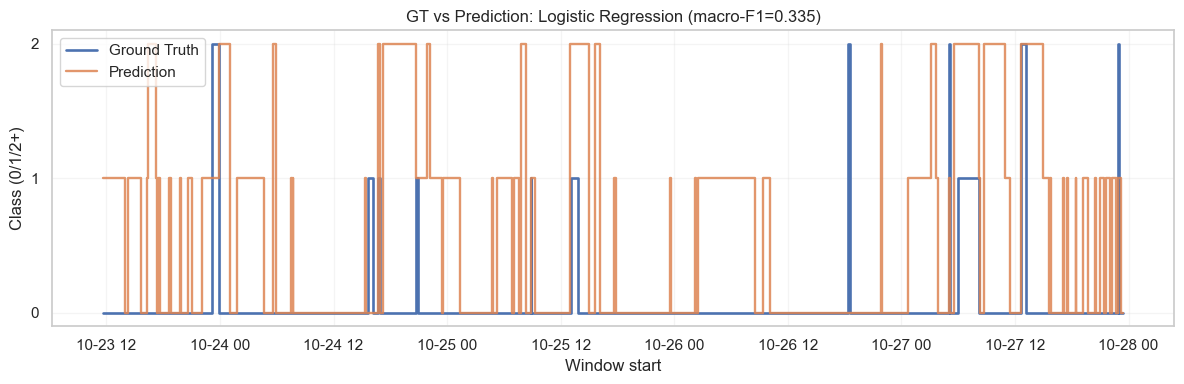

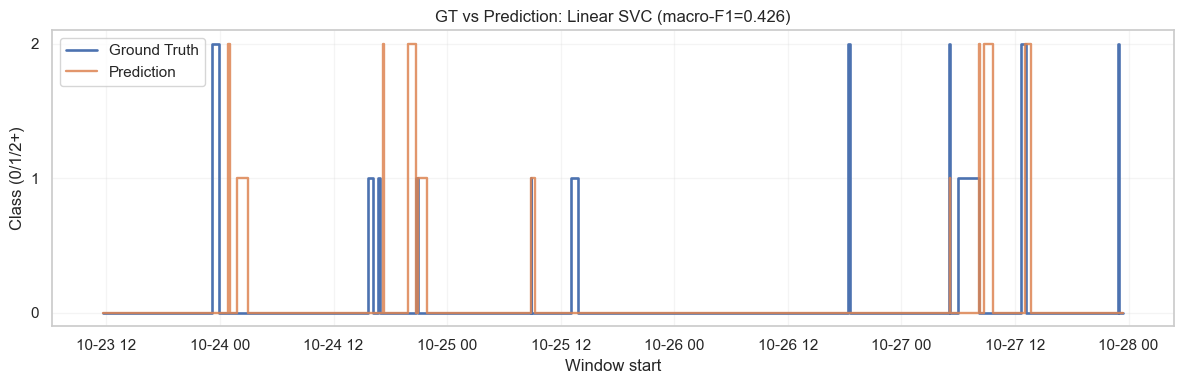

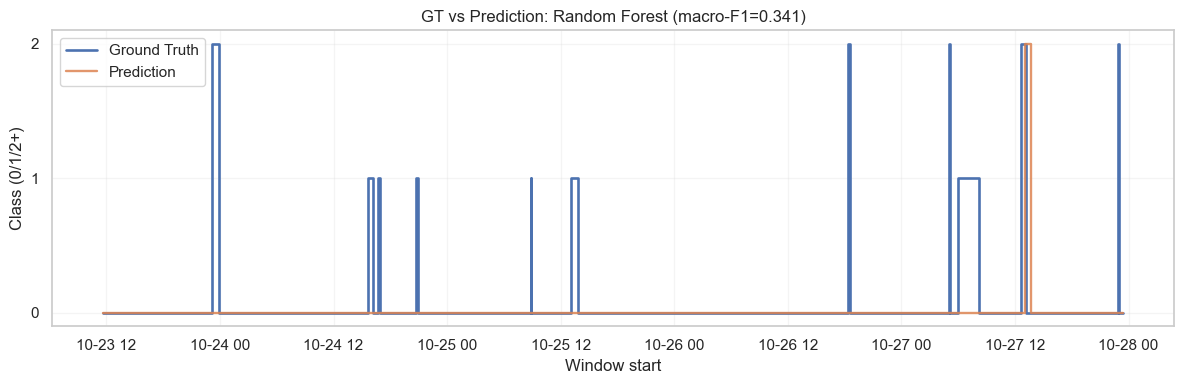

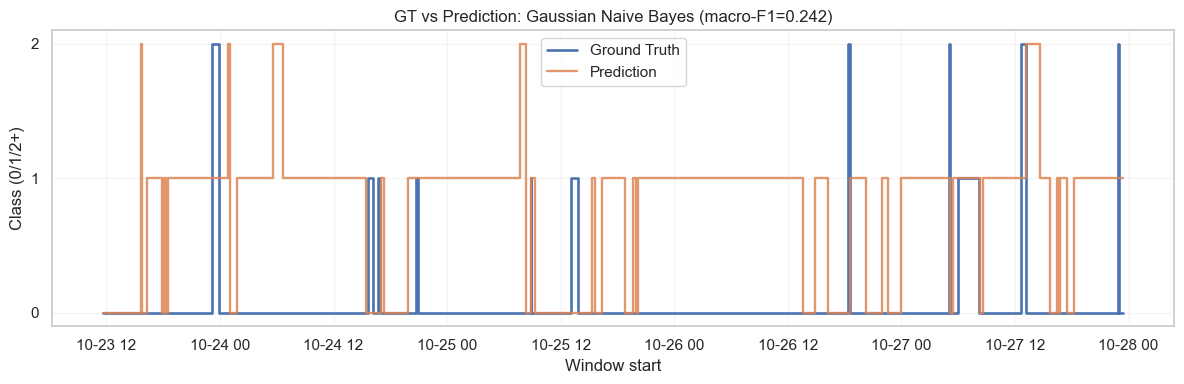

In [ ]:
comparison_df = pd.DataFrame({
    'window_start': test_df['window_start'].values,
    'ground_truth_class': y_test_mc.to_numpy(),
    'prediction_class': best_pred,
})
comparison_df['match'] = comparison_df['ground_truth_class'] == comparison_df['prediction_class']
comparison_df['error_type'] = np.where(
    comparison_df['match'],
    'correct',
    np.where(
        comparison_df['prediction_class'] < comparison_df['ground_truth_class'],
        'under_predict',
        'over_predict',
    ),
)

plot_n = min(300, len(comparison_df))

# GT vs prediction plot for each model.
model_order = list(models.keys())
metric_map = results_df.set_index('model')['macro_f1'].to_dict()

for name in model_order:
    model_plot_df = pd.DataFrame({
        'window_start': test_df['window_start'].values,
        'ground_truth_class': y_test_mc.to_numpy(),
        'prediction_class': predictions[name],
    }).iloc[:plot_n].copy()

    plt.figure(figsize=(12, 4))
    plt.step(
        model_plot_df['window_start'],
        model_plot_df['ground_truth_class'],
        where='post',
        label='Ground Truth',
        linewidth=1.9,
    )
    plt.step(
        model_plot_df['window_start'],
        model_plot_df['prediction_class'],
        where='post',
        label='Prediction',
        linewidth=1.7,
        alpha=0.85,
    )
    plt.title(f"GT vs Prediction: {name} (macro-F1={metric_map.get(name, np.nan):.3f})")
    plt.xlabel('Window start')
    plt.ylabel('Class (0/1/2+)')
    plt.yticks([0, 1, 2])
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# saving the final result if necessary
results_path = '../bgl_window_model_comparison_multiclass.csv'
predictions_path = '../bgl_window_best_model_predictions_multiclass.csv'

results_df.to_csv(results_path, index=False)
comparison_df.to_csv(predictions_path, index=False)

Saved metrics to: ../bgl_window_model_comparison_multiclass.csv
Saved predictions to: ../bgl_window_best_model_predictions_multiclass.csv
Best model: Linear SVC
Best macro-F1: 0.4257
Best accuracy: 0.9152
